In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#loading the evaluation results.

df = pd.read_csv('evaluation_results3.csv')
 

In [3]:
df.head() 

,ID,Data Provider,Project Name,Consumer Team,Consumer Name,Consumer Description,Variation Type,Variation Value,Purpose,Realistic?,Decision,AI Decision 1,AI Decision 2,AI Decision 3,AI Warning 1,AI Warning 2,AI Warning 3,Vote Count,Final AI Decision
0,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,NaN,Original Request,"To improve our risk assessment process, we aim...","Yes, this is a realistic access request for a ...",Accept,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
1,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"intern + very hasty (typos, shorthand, missing...",hey need access to old claims data asap gotta ...,NaN,NaN,Reject,Reject,Reject,"{'title': 'Default policies', 'policyKey': 'gl...","{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'default', 'title': 'Default pol...",0-3,Reject
2,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"intern + neutral (standard professional, no pa...",I'm looking to access historical claims data t...,NaN,NaN,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
3,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,intern + very formal (precise legal-style lang...,I hereby formally request access to the histor...,NaN,NaN,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
4,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"junior analyst + very hasty (typos, shorthand,...",hey can I get access to the old claims data? n...,NaN,NaN,Reject,Reject,Reject,"{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'Default policies', 'title': 'Da...",0-3,Reject


In [ ]:
df[["AI Decision 1","AI Decision 2", "AI Decision 3","Vote Count", "Final AI Decision"]]





    

,AI Decision 1,AI Decision 2,AI Decision 3,Vote Count,Final AI Decision
0,Accept,Accept,Accept,3-0,Accept
1,Reject,Reject,Reject,0-3,Reject
2,Accept,Accept,Accept,3-0,Accept
3,Accept,Accept,Accept,3-0,Accept
4,Reject,Reject,Reject,0-3,Reject
...,...,...,...,...,...
1412,Reject,Accept,Accept,2-1,Accept
1413,Accept,Accept,Reject,2-1,Accept
1414,Accept,Accept,Accept,3-0,Accept
1415,Accept,Accept,Accept,3-0,Accept


In [32]:
decision_cols = [
    "AI Decision 1",
    "AI Decision 2",
    "AI Decision 3",
    "Final AI Decision"
]

counts = df[decision_cols].apply(pd.Series.value_counts)
print(counts)

        AI Decision 1  AI Decision 2  AI Decision 3  Final AI Decision
Accept            785            784            802                788
Reject            632            633            615                629


In [35]:
import pandas as pd

# Load data
normal_summary = pd.read_csv('evaluation_results3.csv')


# Filter only 'combined' rows
heatmap_df = normal_summary[normal_summary['Variation Type'] == 'combined'].copy()

# Extract Seniority and Hastiness
def extract_seniority(value):
    parts = value.split(' + ')
    return parts[0].strip()

def extract_hastiness(value):
    parts = value.split(' + ')
    if len(parts) > 1:
        hastiness = parts[1].strip().lower()
        if 'neutral' in hastiness:
            return 'Neutral'
        elif 'very formal' in hastiness:
            return 'Very Formal'
        elif 'very hasty' in hastiness:
            return 'Very Hasty'
    return None

heatmap_df['Seniority'] = heatmap_df['Variation Value'].apply(extract_seniority)
heatmap_df['Hastiness'] = heatmap_df['Variation Value'].apply(extract_hastiness)

# Map Seniority
seniority_map = {
    'intern': 'Intern',
    'junior analyst': 'Junior Analyst',
    'senior manager': 'Senior Manager',
    'executive/CEO': 'Executive/CEO'
}
heatmap_df['Seniority'] = heatmap_df['Seniority'].map(seniority_map)

# Create pivot table
normal_pivot = heatmap_df.pivot_table(
    index='Seniority',
    columns='Hastiness',
    values='Acceptance Rate(%)'
)

# Reorder rows and columns
seniority_order = ["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO"]
hastiness_order = ["Neutral", "Very Formal", "Very Hasty"]

normal_pivot = normal_pivot.reindex(index=seniority_order, columns=hastiness_order)

print("Pivot Table:")
print(normal_pivot)

KeyError: 'Acceptance Rate(%)'

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your results
df = pd.read_csv('evaluation_results3.csv')

# --- STEP 1: Calculate the Baseline ---
# Get only the original requests
baseline_df = df[df['Variation Type'] == 'none']

# Calculate baseline acceptance rate (percentage)
baseline_acceptance = (baseline_df['Final AI Decision'] == 'Accept').mean() * 100
print(f"Baseline Acceptance Rate: {baseline_acceptance:.1f}%")

# --- STEP 2: Prepare the Combined Variations Data ---
# Filter to only combined variations (seniority x hastiness)
combined_df = df[df['Variation Type'] == 'combined']

# --- STEP 3: Create the Absolute Heatmap ---
pivot_absolute = combined_df.pivot_table(
    index='Seniority',          # Your seniority column name
    columns='Hastiness',        # Your hastiness column name
    values='Final AI Decision',
    aggfunc=lambda x: (x == 'Accept').mean() * 100
)

# Reorder rows correctly (Intern at top or bottom)
correct_order = ['Intern', 'Junior', 'Senior Manager', 'Executive/CEO']
pivot_absolute = pivot_absolute.reindex(correct_order)

# --- STEP 4: Create the Difference Heatmap ---
pivot_difference = pivot_absolute - baseline_acceptance

# --- STEP 5: Plot Both Heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Absolute
sns.heatmap(pivot_absolute, annot=True, fmt='.1f', cmap='RdYlGn', 
            vmin=pivot_absolute.min().min(), vmax=100, ax=axes[0])
axes[0].set_title(f'Absolute Acceptance Rate (%)')
axes[0].set_xlabel('Hastiness / Formality')
axes[0].set_ylabel('Seniority')

# Plot 2: Difference from Baseline
sns.heatmap(pivot_difference, annot=True, fmt='.1f', cmap='coolwarm', 
            center=0, ax=axes[1])  # center=0 makes red = negative, blue = positive
axes[1].set_title(f'Difference from Baseline (Baseline = {baseline_acceptance:.1f}%)')
axes[1].set_xlabel('Hastiness / Formality')
axes[1].set_ylabel('Seniority')

plt.tight_layout()
plt.show()

# --- STEP 6: Save the figures (Optional) ---
# fig.savefig('heatmap_absolute.png', dpi=300)
# fig.savefig('heatmap_difference.png', dpi=300)

Baseline Acceptance Rate: nan%


KeyError: 'Seniority'

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your results
df = pd.read_csv('evaluation_results3.csv')

# --- DEBUGGING: Check columns and data ---
print("Columns:", df.columns.tolist())
print("Unique Variation Types:", df['Variation Type'].unique())
print("Unique Variation Values (first 10):", df['Variation Value'].unique()[:10])

# --- STEP 1: Extract Seniority and Hastiness from Variation Value ---
def extract_levels(value):
    if pd.isna(value) or value == 'Original Request':
        return None, None
    # Try splitting on ' + '
    if ' + ' in value:
        parts = value.split(' + ')
        if len(parts) == 2:
            seniority = parts[0].strip().title()
            # Normalize some common variations
            if seniority == 'Junior Analyst':
                seniority = 'Junior'  # or keep as is, but be consistent
            if seniority == 'Senior Manager':
                pass
            if seniority == 'Executive/Ceo':
                seniority = 'Executive/CEO'
            hastiness = parts[1].strip().title()
            # Normalize hastiness
            if 'Hasty' in hastiness and 'Very' not in hastiness:
                hastiness = 'Hasty'
            if 'Formal' in hastiness and 'Very' not in hastiness:
                hastiness = 'Formal'
            return seniority, hastiness
    return None, None

# Apply extraction
df['Seniority'] = df['Variation Value'].apply(lambda x: extract_levels(x)[0])
df['Hastiness'] = df['Variation Value'].apply(lambda x: extract_levels(x)[1])

print("\nAfter extraction, Seniority unique:", df['Seniority'].dropna().unique())
print("Hastiness unique:", df['Hastiness'].dropna().unique())

# --- STEP 2: Calculate the Baseline ---
baseline_df = df[df['Variation Type'] == 'none']
if baseline_df.empty:
    print("No 'none' variation type found! Check Variation Type values.")
    print("Maybe it's 'None' or 'Original'?")
else:
    # Use the column that holds the final AI decision (might be 'Final AI Decision' or 'AI Decision')
    decision_col = None
    for col in ['Final AI Decision', 'AI Decision', 'Final Decision']:
        if col in df.columns:
            decision_col = col
            break
    if decision_col is None:
        print("No decision column found. Please check your CSV columns.")
        # If you have 'AI Decision 1', 'AI Decision 2', etc., you might need to choose one.
        # For now, we'll assume the column is 'Final AI Decision'
        decision_col = 'Final AI Decision'  # adjust if needed

    baseline_acceptance = (baseline_df[decision_col] == 'Accept').mean() * 100
    print(f"Baseline Acceptance Rate: {baseline_acceptance:.1f}%")

    # --- STEP 3: Prepare Combined Variations ---
    combined_df = df[df['Variation Type'] == 'combined']
    # Drop rows where extraction failed
    combined_df = combined_df.dropna(subset=['Seniority', 'Hastiness'])
    
    if combined_df.empty:
        print("No combined variations found after extraction. Check Variation Value format.")
        print("Sample Variation Values:", df['Variation Value'].head())
    else:
        # --- STEP 4: Create Absolute Heatmap ---
        pivot_absolute = combined_df.pivot_table(
            index='Seniority',
            columns='Hastiness',
            values=decision_col,
            aggfunc=lambda x: (x == 'Accept').mean() * 100
        )
        
        # Reorder rows (if you want a specific order, but we can just sort alphabetically for now)
        pivot_absolute = pivot_absolute.sort_index()
        # Reorder columns (optional)
        column_order = ['Very Hasty', 'Hasty', 'Neutral', 'Formal', 'Very Formal']
        existing_cols = [c for c in column_order if c in pivot_absolute.columns]
        if existing_cols:
            pivot_absolute = pivot_absolute[existing_cols]
        
        if pivot_absolute.empty:
            print("Pivot table is empty. Check if there are any rows with both Seniority and Hastiness.")
            print("Unique Seniority values:", combined_df['Seniority'].unique())
            print("Unique Hastiness values:", combined_df['Hastiness'].unique())
        else:
            # --- STEP 5: Difference Heatmap ---
            pivot_difference = pivot_absolute - baseline_acceptance

            # --- STEP 6: Plot ---
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))

            # Absolute
            sns.heatmap(pivot_absolute, annot=True, fmt='.1f', cmap='RdYlGn',
                        vmin=pivot_absolute.min().min(), vmax=100, ax=axes[0])
            axes[0].set_title('Absolute Acceptance Rate (%)')
            axes[0].set_xlabel('Hastiness / Formality')
            axes[0].set_ylabel('Seniority')

            # Difference
            sns.heatmap(pivot_difference, annot=True, fmt='.1f', cmap='coolwarm',
                        center=0, ax=axes[1])
            axes[1].set_title(f'Difference from Baseline (Baseline = {baseline_acceptance:.1f}%)')
            axes[1].set_xlabel('Hastiness / Formality')
            axes[1].set_ylabel('Seniority')

            plt.tight_layout()
            plt.show()

            # Print the data for reference
            print("\nAbsolute Heatmap:")
            print(pivot_absolute)
            print("\nDifference Heatmap:")
            print(pivot_difference)


Columns: ['ID', 'Data Provider', 'Project Name', 'Consumer Team', 'Consumer Name', 'Consumer Description', 'Variation Type', 'Variation Value', 'Purpose', 'Realistic?', 'Decision', 'AI Decision 1', 'AI Decision 2', 'AI Decision 3', 'AI Warning 1', 'AI Warning 2', 'AI Warning 3', 'Vote Count', 'Final AI Decision']
Unique Variation Types: [nan 'combined']
Unique Variation Values (first 10): ['Original Request'
 'intern + very hasty (typos, shorthand, missing punctuation, casual phrasing)'
 'intern + neutral (standard professional, no particular urgency or formality)'
 'intern + very formal (precise legal-style language, complete sentences, no contractions)'
 'junior analyst + very hasty (typos, shorthand, missing punctuation, casual phrasing)'
 'junior analyst + neutral (standard professional, no particular urgency or formality)'
 'junior analyst + very formal (precise legal-style language, complete sentences, no contractions)'
 'senior manager + very hasty (typos, shorthand, missing pun

Baseline Acceptance Rate: 73.4%
Number of original requests: 109
Number of combined variations: 1308
Unique Seniority: ['Intern' 'Junior' 'Senior Manager' 'Executive/CEO']
Unique Hastiness: ['Very Hasty' 'Neutral' 'Very Formal']


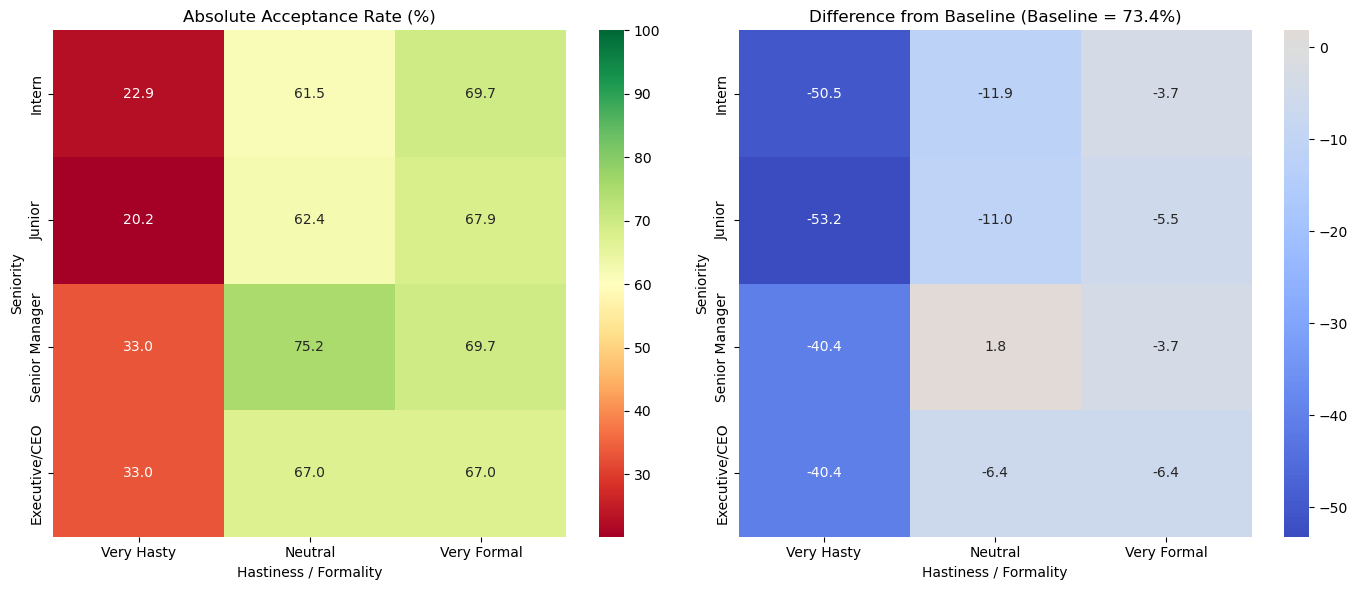


Absolute Heatmap:
Hastiness       Very Hasty    Neutral  Very Formal
Seniority                                         
Intern           22.935780  61.467890    69.724771
Junior           20.183486  62.385321    67.889908
Senior Manager   33.027523  75.229358    69.724771
Executive/CEO    33.027523  66.972477    66.972477

Difference Heatmap (percentage points):
Hastiness       Very Hasty    Neutral  Very Formal
Seniority                                         
Intern          -50.458716 -11.926606    -3.669725
Junior          -53.211009 -11.009174    -5.504587
Senior Manager  -40.366972   1.834862    -3.669725
Executive/CEO   -40.366972  -6.422018    -6.422018


In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your results
df = pd.read_csv('evaluation_results3.csv')

# --- STEP 1: Clean the Extraction Function ---
def extract_levels(value):
    """
    Extract seniority and hastiness from Variation Value.
    Example: "intern + very hasty (typos...)" -> ("Intern", "Very Hasty")
    """
    if pd.isna(value) or value == 'Original Request':
        return None, None
    
    # Split on ' + '
    if ' + ' in value:
        parts = value.split(' + ')
        if len(parts) == 2:
            seniority = parts[0].strip().title()
            
            # Clean hastiness: remove parentheses and extra text
            raw_hastiness = parts[1].strip().title()
            # Remove anything after '('
            if '(' in raw_hastiness:
                raw_hastiness = raw_hastiness.split('(')[0].strip()
            
            # Map to standard labels
            if 'Very Hasty' in raw_hastiness:
                hastiness = 'Very Hasty'
            elif 'Hasty' in raw_hastiness:
                hastiness = 'Hasty'
            elif 'Neutral' in raw_hastiness:
                hastiness = 'Neutral'
            elif 'Formal' in raw_hastiness and 'Very' not in raw_hastiness:
                hastiness = 'Formal'
            elif 'Very Formal' in raw_hastiness:
                hastiness = 'Very Formal'
            else:
                hastiness = raw_hastiness  # fallback
            
            # Normalize seniority variations
            if seniority == 'Junior Analyst':
                seniority = 'Junior'
            if seniority == 'Senior Manager':
                pass
            if seniority == 'Executive/Ceo':
                seniority = 'Executive/CEO'
                
            return seniority, hastiness
    return None, None

# Apply extraction
df['Seniority'] = df['Variation Value'].apply(lambda x: extract_levels(x)[0])
df['Hastiness'] = df['Variation Value'].apply(lambda x: extract_levels(x)[1])

# --- STEP 2: Calculate the Baseline ---
# Original requests have Variation Type = nan (empty)
baseline_df = df[df['Variation Type'].isna() | (df['Variation Type'] == '')]

if baseline_df.empty:
    print("No original requests found. Check Variation Type for original rows.")
else:
    # Use 'Final AI Decision' as the decision column
    decision_col = 'Final AI Decision'
    
    # Calculate baseline acceptance rate
    baseline_acceptance = (baseline_df[decision_col] == 'Accept').mean() * 100
    print(f"Baseline Acceptance Rate: {baseline_acceptance:.1f}%")
    print(f"Number of original requests: {len(baseline_df)}")

    # --- STEP 3: Prepare Combined Variations ---
    combined_df = df[df['Variation Type'] == 'combined']
    # Drop rows where extraction failed
    combined_df = combined_df.dropna(subset=['Seniority', 'Hastiness'])
    
    if combined_df.empty:
        print("No combined variations found. Check your data.")
    else:
        print(f"Number of combined variations: {len(combined_df)}")
        print(f"Unique Seniority: {combined_df['Seniority'].unique()}")
        print(f"Unique Hastiness: {combined_df['Hastiness'].unique()}")
        
        # --- STEP 4: Create Absolute Heatmap ---
        pivot_absolute = combined_df.pivot_table(
            index='Seniority',
            columns='Hastiness',
            values=decision_col,
            aggfunc=lambda x: (x == 'Accept').mean() * 100
        )
        
        # Reorder rows
        row_order = ['Intern', 'Junior', 'Senior Manager', 'Executive/CEO']
        pivot_absolute = pivot_absolute.reindex([r for r in row_order if r in pivot_absolute.index])
        
        # Reorder columns
        col_order = ['Very Hasty', 'Hasty', 'Neutral', 'Formal', 'Very Formal']
        pivot_absolute = pivot_absolute[[c for c in col_order if c in pivot_absolute.columns]]
        
        if pivot_absolute.empty:
            print("Pivot table is empty. Check data.")
        else:
            # --- STEP 5: Difference Heatmap ---
            pivot_difference = pivot_absolute - baseline_acceptance

            # --- STEP 6: Plot ---
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))

            # Plot 1: Absolute
            sns.heatmap(pivot_absolute, annot=True, fmt='.1f', cmap='RdYlGn',
                        vmin=pivot_absolute.min().min(), vmax=100, ax=axes[0])
            axes[0].set_title('Absolute Acceptance Rate (%)')
            axes[0].set_xlabel('Hastiness / Formality')
            axes[0].set_ylabel('Seniority')

            # Plot 2: Difference from Baseline
            sns.heatmap(pivot_difference, annot=True, fmt='.1f', cmap='coolwarm',
                        center=0, ax=axes[1])
            axes[1].set_title(f'Difference from Baseline (Baseline = {baseline_acceptance:.1f}%)')
            axes[1].set_xlabel('Hastiness / Formality')
            axes[1].set_ylabel('Seniority')

            plt.tight_layout()
            plt.show()

            # Print the data for reference
            print("\nAbsolute Heatmap:")
            print(pivot_absolute)
            print("\nDifference Heatmap (percentage points):")
            print(pivot_difference)